# Linear Regression Model - Draft 2

This draft improves upon Draft 1 by introducing a structured, end-to-end pipeline for the linear regression model, guided by relevant research papers from the literature review to align with established practices in e-waste bin fill-level prediction. 

Features = Fill_percentage, Month, Is_weekend, Days_since_last_REC

Target = Next_day_fill_percentage

‌



In [1]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SA61team5/AD-tableA")

df = pd.DataFrame(dataset["train"])

print(df.shape)


(27601, 10)


In [2]:
df.head()

,Index,ContainerID,Timestamp,Fill_percentage,Rec,Cidx,Month,Is_weekend,Days_since_last_REC,Next_day_fill_percentage
0,0,1000,2021-01-16 13:28:00,52.5,1,0.0,1,1,0,52.5
1,1,1000,2021-01-17 12:34:00,52.5,0,0.0,1,1,1,52.5
2,2,1000,2021-01-18 12:41:00,52.5,0,0.0,1,0,2,52.5
3,3,1000,2021-01-19 12:48:00,52.5,0,0.0,1,0,3,52.5
4,4,1000,2021-01-20 18:27:00,52.5,0,0.0,1,0,4,52.5


## Time-based train-test split

Instead of randomly splitting the data, earlier records will be used for training while later records are reserved for testing.

In [3]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
split_date = df["Timestamp"].quantile(0.75)

train_df = df[df["Timestamp"] <= split_date]
test_df  = df[df["Timestamp"] > split_date]

features = ["Fill_percentage", "Month", "Is_weekend", "Days_since_last_REC"]

X_encoded = pd.get_dummies(features, columns=["ContainerID"], drop_first=True)

X_train = train_df[features]
y_train = train_df["Next_day_fill_percentage"]

X_test  = test_df[features]
y_test  = test_df["Next_day_fill_percentage"]

## Model Training

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

In [5]:
y_pred = model.predict(X_test)

## Model Evaluation
Mean Absolute Error (MAE) is used to measure the average absolute difference between the predicted and actual bin fill levels, indicating how far predictions typically deviate from actual fill levels. (Ferrer & Alba, 2019; Krishna et al., 2025).

Root Mean Squared Error (RMSE) is used to assess the impact of large errors on planning decisions (Krishna et al., 2025).

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE  : 12.42
RMSE : 19.05


## Intepreting Evaluation Results
1) MAE = 12.42

    On average, the model’s predicted bin fill level differs from the actual fill level by about 12.4 percentage points.

2) RMSE = 19.05

    RMSE indicates that while most predictions deviate from the actual fill level by about 12.4 percentage points, there are cases where larger errors occur, with deviations of up to around 19 percentage points. These larger errors may occur during irregular fill behaviour, such as sudden increases in usage or or variations related to collection schedules.

## Partial Dependence Plot 
Partial Dependence Plots were used to analyse how each feature influences the predicted next fill level while holding other features constant. 

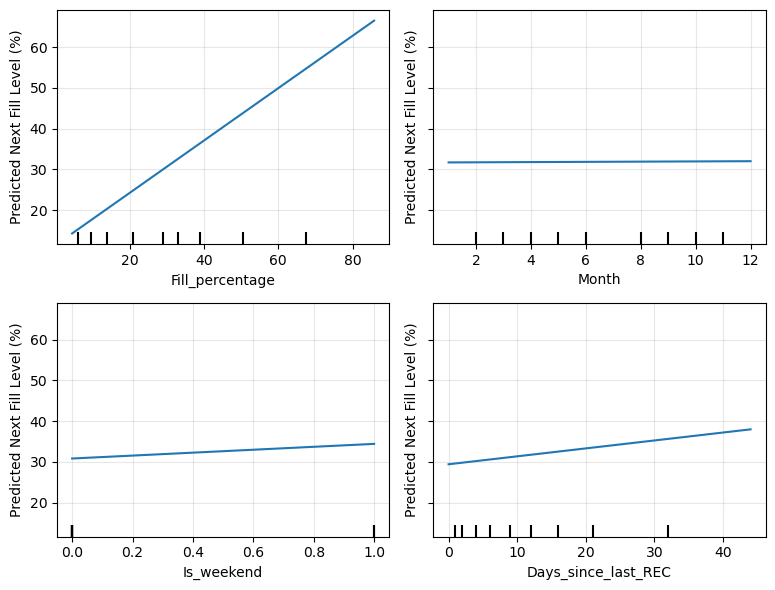

In [7]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 6)
)

disp = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features,
    ax=ax,
    grid_resolution=60
)

for i, axi in enumerate(ax.flat):
    axi.set_xlabel(features[i], fontsize=10)
    axi.set_ylabel("Predicted Next Fill Level (%)", fontsize=10)
    axi.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

The graph for fill_percentage shows a strong positive linear relationship with the predicted next-day fill level. As the current fill level increases, the predicted next-day fill level rises proportionally.

The graph for month shows a nearly flat trend, indicating that seasonal effects, including holiday periods or technology sales cycles, have limited influence on next-day fill level predictions.

The graph for is_weekend shows a slight positive effect on predicted fill levels during weekends compared to weekdays. However, the magnitude of this effect is relatively small.

The graph for days_since_last_REC shows a positive relationship with the predicted next-day fill level. After capping extreme values, this feature reflects a modest increase in predicted fill as time since last collection grows, though its influence remains secondary compared to the current fill level. 

## References

Brouwer, Y., Ana Paula Barbosa-Póvoa, António Pais Antunes, & Rodrigues, T. (2023). Comparison of different waste bin monitoring approaches: An exploratory study. Waste Management & Research (Online), 41(10), 1570–1583. https://doi.org/10.1177/0734242x231160691
‌

Ferrer, J., & Alba, E. (2019). BIN-CT: Urban waste collection based on predicting the container fill level. Biosystems, 186, 103962. https://doi.org/10.1016/j.biosystems.2019.04.006

Krishna, S. R., Bhukya Kranthikumar, Swathy Vodithala, Waseem, Md. Sharfuddin., & Kireet Muppavaram. (2025). A Machine Learning Framework For Predictive Waste Management Optimization In Smart Cities. International Journal of Environmental Sciences, 11(12s), 328–334. https://doi.org/10.64252/zp92vp11

In [9]:
# Test prediction

X_test_manual = pd.DataFrame([{
    "Fill_percentage": 40,
    "Month": 1,
    "Is_weekend": 0,
    "Days_since_last_REC": 1
}])

pred = model.predict(X_test_manual)
print("Prediction:", pred)

Prediction: [33.67483599]
